In [19]:
import pandas as pd

df_2008 = pd.read_csv('../data/raw/DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv')
print(df_2008.shape)
print(df_2008.columns.tolist())

(116352, 32)
['DESYNPUF_ID', 'BENE_BIRTH_DT', 'BENE_DEATH_DT', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'BENE_ESRD_IND', 'SP_STATE_CODE', 'BENE_COUNTY_CD', 'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS', 'BENE_HMO_CVRAGE_TOT_MONS', 'PLAN_CVRG_MOS_NUM', 'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD', 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS', 'SP_RA_OA', 'SP_STRKETIA', 'MEDREIMB_IP', 'BENRES_IP', 'PPPYMT_IP', 'MEDREIMB_OP', 'BENRES_OP', 'PPPYMT_OP', 'MEDREIMB_CAR', 'BENRES_CAR', 'PPPYMT_CAR']


In [20]:
print(df_2008['BENE_DEATH_DT'].notna().sum())
print(df_2008['BENE_HI_CVRAGE_TOT_MONS'].value_counts().sort_index())

1814
BENE_HI_CVRAGE_TOT_MONS
0       5294
1        503
2        459
3        477
4        483
5        574
6        565
7        627
8        639
9        733
10       796
11       900
12    104302
Name: count, dtype: int64


In [21]:
df_2009 = pd.read_csv('../data/raw/DE1_0_2009_Beneficiary_Summary_File_Sample_1.csv')
df_2010 = pd.read_csv('../data/raw/DE1_0_2010_Beneficiary_Summary_File_Sample_1.csv')

full_08 = df_2008[df_2008['BENE_HI_CVRAGE_TOT_MONS'] == 12]['DESYNPUF_ID']
full_09 = df_2009[df_2009['BENE_HI_CVRAGE_TOT_MONS'] == 12]['DESYNPUF_ID']
full_10 = df_2010[df_2010['BENE_HI_CVRAGE_TOT_MONS'] == 12]['DESYNPUF_ID']

common_ids = set(full_08) & set(full_09) & set(full_10)
print(len(common_ids))

93558


In [22]:
df_2010_common = df_2010[df_2010['DESYNPUF_ID'].isin(common_ids)].copy()
df_2010_common['total_cost_2010'] = (
    df_2010_common['MEDREIMB_IP'] +
    df_2010_common['MEDREIMB_OP'] +
    df_2010_common['MEDREIMB_CAR']
)
target = df_2010_common[['DESYNPUF_ID', 'total_cost_2010']].copy()
target['total_cost_2010'] = target['total_cost_2010'].clip(lower=0)

print(target.shape)
print((target['total_cost_2010'] < 0).sum())  # should be 0
print(target['total_cost_2010'].describe())

(93558, 2)
0
count     93558.000000
mean       2784.106757
std        5931.472266
min           0.000000
25%         190.000000
50%        1080.000000
75%        2570.000000
max      116910.000000
Name: total_cost_2010, dtype: float64


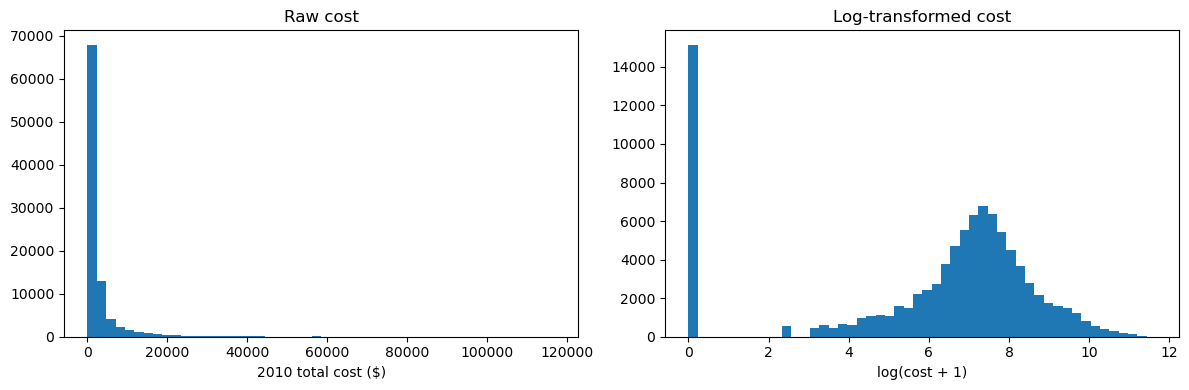

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target['total_cost_2010'], bins=50)
axes[0].set_title('Raw cost')
axes[0].set_xlabel('2010 total cost ($)')

axes[1].hist(np.log1p(target['total_cost_2010']), bins=50)
axes[1].set_title('Log-transformed cost')
axes[1].set_xlabel('log(cost + 1)')

plt.tight_layout()
plt.savefig('../notebooks/cost_distribution.png')
plt.show()

In [24]:
zero_cost_ids = target[target['total_cost_2010'] == 0]['DESYNPUF_ID']
zero_cost_2009 = df_2009[df_2009['DESYNPUF_ID'].isin(zero_cost_ids)]

chronic_cols = ['SP_ALZHDMTA','SP_CHF','SP_CHRNKIDN','SP_CNCR','SP_COPD',
                'SP_DEPRESSN','SP_DIABETES','SP_ISCHMCHT','SP_OSTEOPRS','SP_RA_OA','SP_STRKETIA']

# these are coded 1 = yes, 2 = no, so count where == 1
has_any_chronic = (zero_cost_2009[chronic_cols] == 1).any(axis=1)
print(has_any_chronic.value_counts())

False    12934
True      2204
Name: count, dtype: int64


In [25]:
features = df_2009[df_2009['DESYNPUF_ID'].isin(common_ids)].copy()

features['BENE_BIRTH_DT'] = pd.to_datetime(features['BENE_BIRTH_DT'], format='%Y%m%d')
reference_date = pd.Timestamp('2009-01-01')
features['age'] = (reference_date - features['BENE_BIRTH_DT']).dt.days // 365

features = features[['DESYNPUF_ID', 'age', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'BENE_ESRD_IND']]
features['BENE_ESRD_IND'] = (features['BENE_ESRD_IND'] == 'Y').astype(int)

print(features.shape)
print(features['age'].describe())

(93558, 5)
count    93558.000000
mean        72.124329
std         12.535045
min         25.000000
25%         67.000000
50%         73.000000
75%         80.000000
max        100.000000
Name: age, dtype: float64


In [26]:
chronic_cols = ['SP_ALZHDMTA','SP_CHF','SP_CHRNKIDN','SP_CNCR','SP_COPD',
                'SP_DEPRESSN','SP_DIABETES','SP_ISCHMCHT','SP_OSTEOPRS','SP_RA_OA','SP_STRKETIA']

chronic_2009 = df_2009[df_2009['DESYNPUF_ID'].isin(common_ids)][['DESYNPUF_ID'] + chronic_cols].copy()

# recode 1=yes,2=no into clean 0/1
for col in chronic_cols:
    chronic_2009[col] = (chronic_2009[col] == 1).astype(int)

chronic_2009['chronic_count'] = chronic_2009[chronic_cols].sum(axis=1)

features = features.merge(chronic_2009, on='DESYNPUF_ID')
print(features.shape)
print(features['chronic_count'].value_counts().sort_index())

(93558, 17)
chronic_count
0     24323
1     10445
2     11033
3     11024
4     10574
5      9062
6      7317
7      5240
8      2971
9      1241
10      292
11       36
Name: count, dtype: int64


In [27]:
def get_total_cost(df, ids):
    d = df[df['DESYNPUF_ID'].isin(ids)].copy()
    d['total_cost'] = (d['MEDREIMB_IP'] + d['MEDREIMB_OP'] + d['MEDREIMB_CAR']).clip(lower=0)
    return d[['DESYNPUF_ID', 'total_cost']]

cost_2008 = get_total_cost(df_2008, common_ids).rename(columns={'total_cost': 'cost_2008'})
cost_2009 = get_total_cost(df_2009, common_ids).rename(columns={'total_cost': 'cost_2009'})

features = features.merge(cost_2008, on='DESYNPUF_ID')
features = features.merge(cost_2009, on='DESYNPUF_ID')

features['cost_trend'] = features['cost_2009'] - features['cost_2008']

print(features.shape)
print(features[['cost_2008', 'cost_2009', 'cost_trend']].describe())

(93558, 20)
           cost_2008      cost_2009     cost_trend
count   93558.000000   93558.000000   93558.000000
mean     4646.375297    4883.981274     237.605977
std     10527.159888    9002.408151   11342.435807
min         0.000000       0.000000 -145700.000000
25%       210.000000     450.000000    -310.000000
50%      1310.000000    1960.000000     100.000000
75%      3750.000000    4960.000000    1460.000000
max    170190.000000  154970.000000  136100.000000


In [28]:
final_df = features.merge(target, on='DESYNPUF_ID')
print(final_df.shape)
print(final_df.isnull().sum().sum())  # should be 0

final_df.to_csv('../data/processed/processed_data.csv', index=False)

(93558, 21)
0
